In [22]:
import pandas as pd

In [23]:
df=pd.read_csv("online_retail.csv",encoding="ISO-8859-1")

In [24]:
df.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerI

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [27]:
type(df)

pandas.DataFrame

In [28]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [29]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(5268)

In [31]:
df.drop_duplicates(inplace=True)

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [34]:
df=df[df["CustomerID"].notna()]

In [35]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.6 MB


df.to_csv("online_retail_cleaned.csv",index=False)

In [36]:
import matplotlib.pyplot as plt

In [37]:
top_countries =df["Country"].value_counts().head(10)
top_countries

Country
United Kingdom    356728
Germany             9480
France              8475
EIRE                7475
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1471
Australia           1258
Name: count, dtype: int64

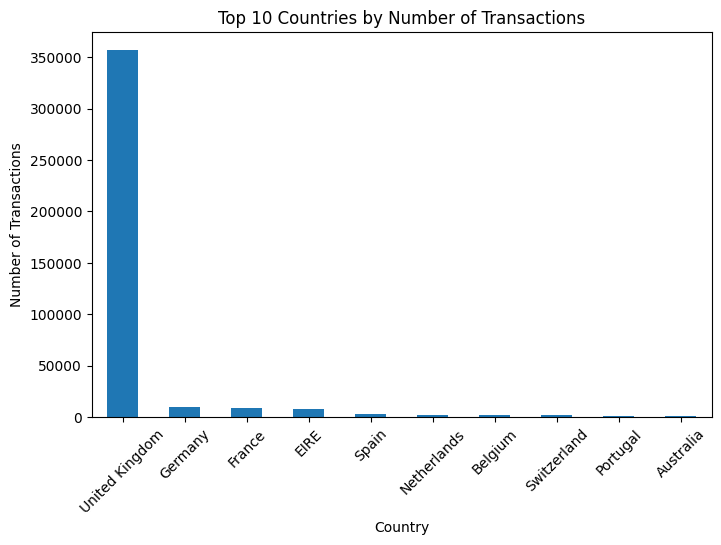

In [ ]:
top_countries.plot(kind="bar",
                   figsize=(8,5))
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

Transaction Activity

Insight: The United Kingdom recorded the highest number of transactions, indicating that it is the company's most active market. The remaining countries had significantly fewer transactions, showing customer activity is concentrated in one region.

Recommendation: Countries strengthening customer engagement in the United Kingdom while expanding marketing campaigns and improving customer acquisition strategies in other countries to increase transaction volumes and reduce relaince on a single market.

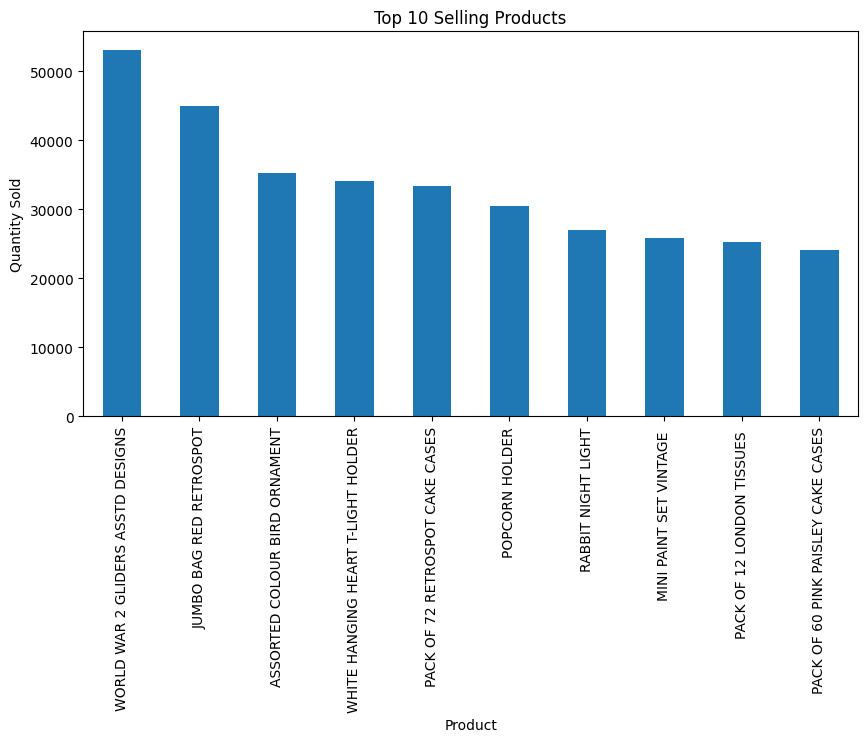

In [39]:
top_products=df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar",
                  figsize=(10,5))
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()

Product Review

Insight: The World War 2 Gliders Asstd Designs is the highest selling product among the top 10 products, outperforming the other items by a noticeable margin.This indicates that customers have a strong preference for this product compared to the rest.

Recommendation: The company should maintain sufficient stock ofthe World War 2 Gliders Asstd Design to continue meeting customer demand. In addition, it should check the features, pricing and marketing strategies that make this product successful and apply similar strategies to improve the sales performance of the other products.

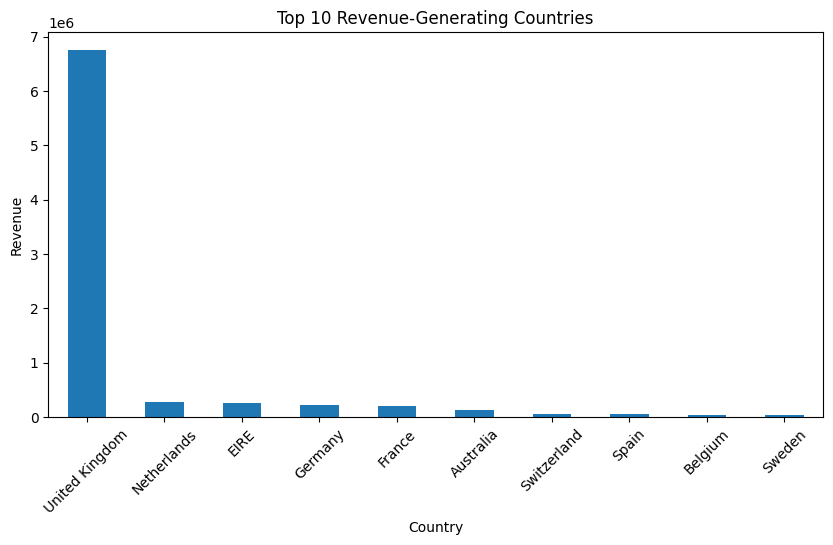

In [40]:
df["Revenue"]=df["Quantity"]*df["UnitPrice"]
revenue_country=df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
revenue_country.plot(kind="bar",
                     figsize=(10,5))
plt.title("Top 10 Revenue-Generating Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Top 10 Countries Contributing to Total Revenue

Insight: The United Kingdom generates the highest revenue for the company by a noticeable high margin, indicating that it is the company's strongest and most profitable market. Revenue from the remaining countries is considerably lower, suggesting opportunities for growth in other countries.

Recommendation: The company should continue strengthening customer loyalty in the United Kingdom through targeted promotions, discounts, coupons and excellent customer service. At the same time, it should investigate the factors limiting sales in other countries such as customer preference, product availability or market reach and implement targeted strategies to increase revenue in those markets.

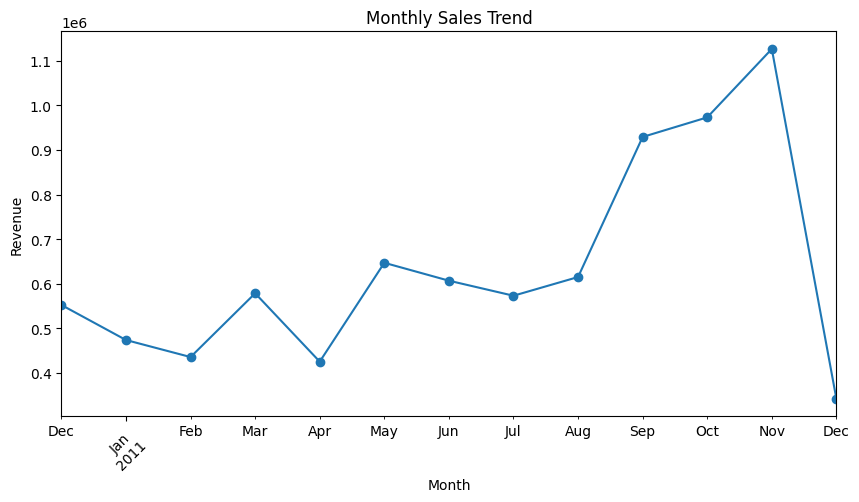

In [41]:
df["Month"]=df["InvoiceDate"].dt.to_period("M")
monthly_sales=df.groupby("Month")["Revenue"].sum()
monthly_sales.plot(kind="line",
                   figsize=(10,5),marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Monthly Sales

Insight: From the monthly sales trend chart, revenue generally increased through out the year reaching its peak at November. This indicates that customer  demand was strongest towards the end of the year either due to seasonal demand or holiday shopping. The sharp decline in December is simply because the dataset available is incomplete.

Recommendation:The company should prepare for adequately for the increased sale during the final quater of the year by ensuring adequate staffing, sufficient inventory and well-planned campaign includding discount or coupon. Since the December dataset was incomplete , the company ensure to collect the complete dataset before planning for December sales to avoid overestimating or underestimating business performance

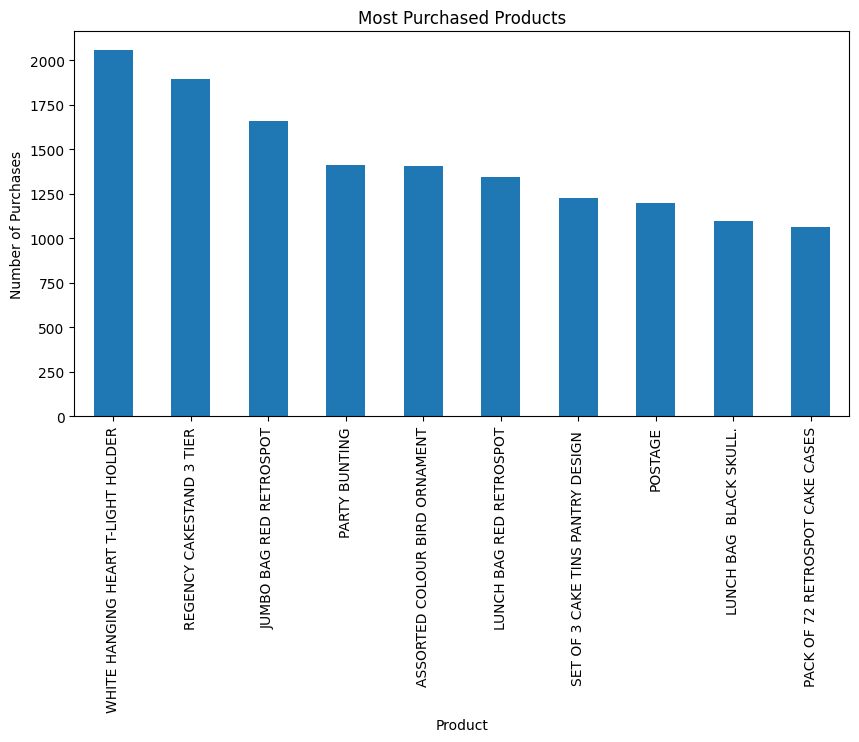

In [42]:
most_purchased=df["Description"].value_counts().head(10)
most_purchased.plot(kind="bar", figsize=(10,5))
plt.title("Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=90)
plt.show()

Most Purchased Product

Insight: The white hanging T-Heart holder is the most purchased product outperforming all other product by a significant margin. It is followed by the regency cakestand 3 tier, although with considerably fewer purchases. This suggests that customer demand is concentrated on a few high performing products.

Recommendation: The company should identify the factors contributing to the sales of the white hanging T-Heart holder and apply similar strategy to other products. In addition, the company should gather customer feedback and analyze factors such as pricing, product quality, seasonality and competition to understand why other products are not performing as well. The findings can then be used to improve sales across the rest of the product range.

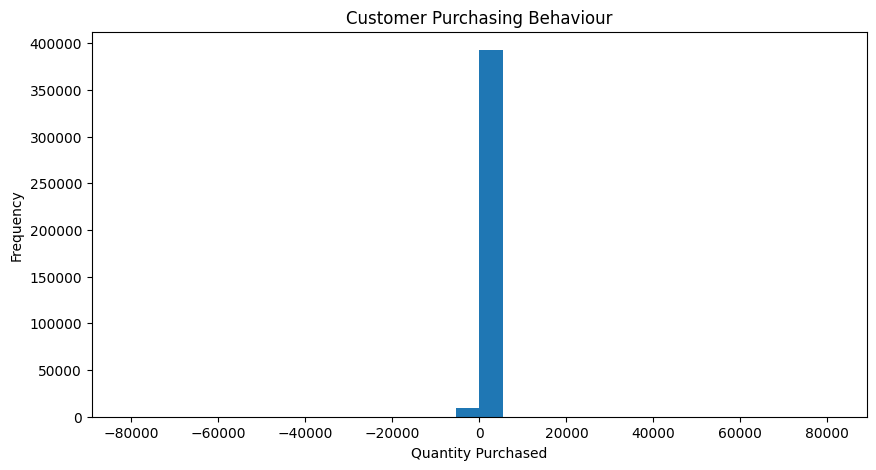

In [43]:
df["Quantity"].plot(kind="hist", bins=30, figsize=(10,5))
plt.title("Customer Purchasing Behaviour")
plt.xlabel("Quantity Purchased")
plt.ylabel("Frequency")
plt.show()

Customer Behaviour Pattern

Insight: The histogram shows that most purchases involve relatively small quantities, while only a small number of transactions involve bulk quantities. This indicates that the business relies heavily on frequent small purchases, with occassional bulk orders.

Recommendatins: The company should continue meeting the needs of the regular customers as they account for the majority of purchases. At the same time, it should introduce bulk order loyalty reward to encourage more customers to place large orders and increase sales



## Conclusion

This project analyzed an online retail sales dataset using Python to transform raw transactional data into meaningful business insights. Through data understanding, data cleaning, exploratory data analysis, and visualization, key sales trends, customer purchasing behavior, product performance, and country-level revenue patterns were identified. The analysis revealed that the United Kingdom generated the highest revenue, World War II Gliders was the top-selling product, sales peaked in November, and most customers purchased in smaller quantities. These findings demonstrate how exploratory data analysis supports data-driven decision-making by helping businesses understand customer behavior, optimize inventory, and improve sales strategies. This project also strengthened practical skills in Python, Pandas, Matplotlib, Seaborn, data cleaning, and exploratory data analysis.